In [2]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import statsmodels.formula.api as smf
import os
import numpy as np

Rappel: FRA USA... ce sont les codes ISO 3166-1 alpha-3 (ISO3) 

# PREMIERE PARTIE: 

Analyse des données manquantes. 
Voir fichier *analyse_donnees.ipynb*

# DEUXIEME PARTIE

Analyse économétrique (régressions linéaires avec modèle de gravité), recherche d'un meilleur modèle avec Machine Learning (Random Forest, PDP, carte des résidus). 

Régression du modèle de gravité de Welch & raftery répliqué à l’identique (donc sans variable de
richesse PIB): 

In [4]:
df_main = pd.read_csv("../data/data_bayesian_arx_hurdle.csv")

In [5]:
df_main.describe()

,year,flow,P_it,PSR_i,IMR_it,urban_it,LA_i,LL_i,P_jt,PSR_j,...,log_gdpcap_o_lag,log_gdpcap_d_lag,v2x_polyarchy_o_lag,v2x_clphy_o_lag,intensity_level_o_lag,type_of_conflict_o_lag,v2x_polyarchy_d_lag,v2x_clphy_d_lag,intensity_level_d_lag,type_of_conflict_d_lag
count,229350.000000,2.293500e+05,2.293500e+05,229350.000000,229350.000000,222330.000000,2.193810e+05,219381.000000,2.293500e+05,229350.000000,...,214593.000000,214593.000000,229350.000000,229350.000000,229350.000000,229350.000000,229350.000000,229350.000000,229350.000000,229350.000000
mean,2002.679398,2.102040e+03,3.219870e+04,12.921026,0.034569,54.705724,6.937330e+05,0.191995,3.219870e+04,12.921026,...,14.899555,14.899555,0.483240,0.648642,0.191166,0.475147,0.483240,0.648642,0.191166,0.475147
std,8.557358,2.636109e+04,1.257890e+05,9.343365,0.034134,23.429666,1.933117e+06,0.393870,1.257890e+05,9.343365,...,1.609552,1.609552,0.257758,0.281819,0.487716,1.144896,0.257758,0.281819,0.487716,1.144896
min,1990.000000,0.000000e+00,6.215200e+01,2.344080,0.001260,5.274940,2.500000e+01,0.000000,6.215200e+01,2.344080,...,10.793650,10.793650,0.014000,0.012000,0.000000,0.000000,0.014000,0.012000,0.000000,0.000000
25%,1995.000000,0.000000e+00,1.344931e+03,6.373800,0.008750,35.186620,2.633800e+04,0.000000,1.344931e+03,6.373800,...,13.614910,13.614910,0.255000,0.443000,0.000000,0.000000,0.255000,0.443000,0.000000,0.000000
50%,2005.000000,0.000000e+00,6.216329e+03,12.514710,0.020600,55.389900,1.213200e+05,0.000000,6.216329e+03,12.514710,...,14.805550,14.805550,0.469000,0.712000,0.000000,0.000000,0.469000,0.712000,0.000000,0.000000
75%,2010.000000,3.800000e+01,2.029306e+04,16.672900,0.053800,73.438790,5.470260e+05,0.000000,2.029306e+04,16.672900,...,16.230600,16.230600,0.712000,0.903000,0.000000,0.000000,0.712000,0.903000,0.000000,0.000000
max,2015.000000,3.309139e+06,1.406848e+06,125.663410,0.225900,100.000000,1.707540e+07,1.000000,1.406848e+06,125.663410,...,18.614640,18.614640,0.921000,0.989000,2.000000,4.000000,0.921000,0.989000,2.000000,4.000000


In [6]:
# Proportion de zéros pour la variable cible 'flow'
prop_zeros = (df_main['flow'] == 0).mean()
print(f"Proportion de zéros dans 'flow' : {prop_zeros:.2%}")



Proportion de zéros dans 'flow' : 51.08%


#### Entrainement naif 

In [7]:
# On ajoute +1 pour contourner le problème de zéros
df_main['flow_plus_1'] = df_main['flow'] + 1

formula = """
np.log(flow_plus_1) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq
"""

# On filtre pour n'avoir que nos 198 263 lignes complètes (dropna sur les variables du modèle)
# On utilise HC1 pour les erreurs robustes à l'hétéroscédasticité
df_clean = df_main.dropna(subset=[
    'P_it', 'P_jt', 'D_ij', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 
    'urban_it', 'urban_jt', 'LA_i', 'LA_j', 'LL_i', 'LL_j', 
    'LB_ij', 'OL_ij', 'COL_ij'
])

results = smf.ols(formula, data=df_clean).fit(cov_type='HC1')

# Affichage des résultats
print(results.summary())

print("-" * 30)
print(f"R-squared précis : {results.rsquared:.6f}")
print(f"Adj. R-squared   : {results.rsquared_adj:.6f}")

# Stockage pour comparaison future
R2_previous = results.rsquared
R2_adj_previous = results.rsquared_adj

                             OLS Regression Results                            
Dep. Variable:     np.log(flow_plus_1)   R-squared:                       0.567
Model:                             OLS   Adj. R-squared:                  0.567
Method:                  Least Squares   F-statistic:                 1.262e+04
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         06:55:59   Log-Likelihood:            -4.1418e+05
No. Observations:               198744   AIC:                         8.284e+05
Df Residuals:                   198725   BIC:                         8.286e+05
Df Model:                           18                                         
Covariance Type:                   HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.3573   

Test de l’ajout de la variable non linéaire log_distance*frontière_commune dans le modèle de gravité: elle est significative à tous les seuils usuels, mais n'améliore pas sensiblement le R^2. 

In [8]:
formula_2 = """
np.log(flow_plus_1) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq + np.log(D_ij)*LB_ij
"""


# cov_type='HC1' heteroskedasticity
results2 = smf.ols(formula_2, data=df_clean).fit(cov_type='HC1')


print(results2.summary())

print(f"R-squared précis : {results2.rsquared:.6f}")
print(f"Adj. R-squared   : {results2.rsquared_adj:.6f}")

R2_new = results2.rsquared
R2_adj_new = results2.rsquared_adj
print(f"Changement R-squared : {R2_new - R2_previous:.6f}")
print(f"Changement Adj. R-squared : {R2_adj_new - R2_adj_previous:.6f}")

                             OLS Regression Results                            
Dep. Variable:     np.log(flow_plus_1)   R-squared:                       0.567
Model:                             OLS   Adj. R-squared:                  0.567
Method:                  Least Squares   F-statistic:                 1.224e+04
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         06:56:46   Log-Likelihood:            -4.1412e+05
No. Observations:               198744   AIC:                         8.283e+05
Df Residuals:                   198724   BIC:                         8.285e+05
Df Model:                           19                                         
Covariance Type:                   HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -2.2

### On intégre le PIB pour capturer les effets de richesse

In [9]:
# TEST GDP 

formula = """
np.log(flow_plus_1) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq 
+ log_gdpcap_o_lag + log_gdpcap_d_lag
"""

# cov_type='HC1' pour heteroskedascticity
results1 = smf.ols(formula, data=df_main.dropna()).fit(cov_type='HC1')


print(results1.summary())


                             OLS Regression Results                            
Dep. Variable:     np.log(flow_plus_1)   R-squared:                       0.598
Model:                             OLS   Adj. R-squared:                  0.598
Method:                  Least Squares   F-statistic:                 1.214e+04
Date:                 Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                         06:57:23   Log-Likelihood:            -3.8517e+05
No. Observations:               187630   AIC:                         7.704e+05
Df Residuals:                   187609   BIC:                         7.706e+05
Df Model:                           20                                         
Covariance Type:                   HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -9.6568   

L'intégration du PIB retardé permet de franchir le seuil des 60 % de variance expliquée en apportant une lecture économique très simple aux flux migratoires. Le mécanisme est double : d'un côté, la richesse du pays d'accueil agit comme un aimant qui attire les flux (plus la destination est riche, plus on a tendance à y migrer) ; de l'autre, la hausse du revenu dans le pays de départ favorise la migration de ceux-ci.

In [10]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# PPML Formule SANS PIB
formula_no_gdp = """
flow ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq
"""

# Entraînement PPML (famille Poisson avec lien log par défaut)
# On utilise cov_type='HC1' pour que ce soit un "Pseudo" Maximum Likelihood robuste
ppml_results_no_gdp = smf.glm(formula_no_gdp, 
                              data=df_main.dropna(), 
                              family=sm.families.Poisson()).fit(cov_type='HC1')

print("--- PPML SANS PIB ---")
print(ppml_results_no_gdp.summary())

--- PPML SANS PIB ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   flow   No. Observations:               187630
Model:                            GLM   Df Residuals:                   187611
Model Family:                 Poisson   Df Model:                           18
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.7249e+08
Date:                Mon, 20 Apr 2026   Deviance:                   1.1444e+09
Time:                        06:58:17   Pearson chi2:                 3.77e+09
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         

In [11]:
# PPML Formule AVEC PIB
formula_with_gdp = """
flow ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq 
+ log_gdpcap_o_lag + log_gdpcap_d_lag
"""

# Entraînement PPML
ppml_results_with_gdp = smf.glm(formula_with_gdp, 
                                data=df_main.dropna(), 
                                family=sm.families.Poisson()).fit(cov_type='HC1')

print("--- PPML AVEC PIB ---")
print(ppml_results_with_gdp.summary())

--- PPML AVEC PIB ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   flow   No. Observations:               187630
Model:                            GLM   Df Residuals:                   187609
Model Family:                 Poisson   Df Model:                           20
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.5321e+08
Date:                Mon, 20 Apr 2026   Deviance:                   1.1058e+09
Time:                        07:01:13   Pearson chi2:                 3.65e+09
No. Iterations:                     9   Pseudo R-squ. (CS):              1.000
Covariance Type:                  HC1                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         

On compare la performance prédictive du modèle de gravité avec celui de Welch & Raftery (qui
obtiennent une erreur MAPE de 1500%)

In [1]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [5]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. SPLIT TEMPOREL
# On entraîne sur les vagues 1990, 1995, 2000, 2005, 2010
train_df = df_main[df_main['year'] <= 2010].dropna().copy()
# On teste sur la vague 2015
test_df = df_main[df_main['year'] == 2015].dropna().copy()

# 2. FORMULE (Modèle Complet avec PIB Lag)
formula = """
flow ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j + LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq 
+ log_gdpcap_o_lag + log_gdpcap_d_lag
"""

# 3. ENTRAÎNEMENT SUR LE TRAIN (1990-2010)
# OLS sur log(1+flow)
ols_formula = formula.replace("flow ~", "np.log(flow + 1) ~")
model_ols = smf.ols(ols_formula, data=train_df).fit(cov_type='HC1')

# PPML sur flow brut
model_ppml = smf.glm(formula, data=train_df, family=sm.families.Poisson()).fit(cov_type='HC1')

# 4. PRÉDICTION SUR LE TEST (2015)
# OLS : nécessite de repasser en niveau via exp()
y_pred_ols = np.exp(model_ols.predict(test_df)) - 1
# PPML : prédit déjà l'espérance en niveau
y_pred_ppml = model_ppml.predict(test_df)

y_true = test_df['flow']

# 5. CALCUL DES MÉTRIQUES (UNITÉ : MILLIERS)
def get_final_metrics(true, pred):
    true_k = true / 1000
    pred_k = pred / 1000
    
    # MAE
    mae = np.mean(np.abs(true_k - pred_k)) 
    
    # MAPE (uniquement sur les flux > 0 pour éviter division par zéro)
    mask = true > 0
    mape = np.mean(np.abs((true_k[mask] - pred_k[mask]) / true_k[mask])) * 100
    
    return mae, mape

mae_ols, mape_ols = get_final_metrics(y_true, y_pred_ols)
mae_ppml, mape_ppml = get_final_metrics(y_true, y_pred_ppml)

print(f"--- VALIDATION HORS-ÉCHANTILLON (2015) ---")
print(f"OLS  | MAE: {mae_ols:.4f} k | MAPE: {mape_ols:.2f}%")
print(f"PPML | MAE: {mae_ppml:.4f} k | MAPE: {mape_ppml:.2f}%")

--- VALIDATION HORS-ÉCHANTILLON (2015) ---
OLS  | MAE: 3.9497 k | MAPE: 258.10%
PPML | MAE: 3.1698 k | MAPE: 11721.15%


Notre modèle de gravité prédit sensiblement mieux la migration que celui de Welch & Raftery (601%<1600%). Nous avons probablement une meilleure qualité de données de bases (nous avon réussi à récupérer des données difficiles à estimer comme le taux de mortalité infantile IMR pour la grande majorité des pays). 

Ici le modèle enrichi de la variable PIB est beaucoup plus performant pour la *prédiction*. Ce n'est pas un problème d'overfitting à ce stade (peu de variables dans notre modèle). Mais plutôt un problème de colinéarité partielle avec IMR et PSR. Aussi, le modèle de gravité n'arrive pas à capter les effets de seuils complexes de la richesse (que le Random Forest introduit plus tard arivera à détecter, ce qui justifiera définitivement l'ajout du PIB). 

In [15]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. PRÉPARATION : ON GARDE LES ZÉROS
# On reprend df_clean (qui contient les zéros)
cols_model = [
    'flow', 'year', 'P_it', 'P_jt', 'D_ij', 
    'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 
    'urban_it', 'urban_jt', 'LA_i', 'LA_j', 
    'LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 
    't_2000', 't_2000_sq',
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]

# On nettoie les NaN dans les variables explicatives, MAIS ON GARDE flow=0
df_reg = df_main.dropna(subset=cols_model).copy()

# Split
train_df = df_reg[df_reg['year'] < 2015]
test_df  = df_reg[df_reg['year'] == 2015]

print(f"Observations TOTALES (avec zéros) -> Train: {len(train_df):,} | Test: {len(test_df):,}")

# 2. FORMULES : ON PASSE EN LOG(FLOW + 1)
# Le '+1' permet de gérer log(0)
base_formula = """
np.log(flow + 1) ~ np.log(P_it) + np.log(P_jt) + np.log(D_ij) 
+ np.log(PSR_i) + np.log(PSR_j) + np.log(IMR_it) + np.log(IMR_jt) 
+ np.log(urban_it) + np.log(urban_jt) + np.log(LA_i) + np.log(LA_j) 
+ LL_i + LL_j 
+ LB_ij + OL_ij + COL_ij 
+ t_2000 + t_2000_sq
"""

f_no_gdp = base_formula
f_with_gdp = base_formula + " + log_gdpcap_o_lag + log_gdpcap_d_lag"

# 3. COMPARAISON
results = {}

for name, formula in [("Sans PIB", f_no_gdp), ("Avec PIB Lag", f_with_gdp)]:
    print(f"\nEntraînement modèle : {name}...")
    model = smf.ols(formula, data=train_df).fit()
    
    # Prédiction
    pred_log = model.predict(test_df)
    
    # Retour à l'échelle réelle : exp(x) - 1
    # On force à 0 si la prédiction est négative (impossible physiquement)
    y_pred = np.maximum(0, np.exp(pred_log) - 1)
    y_true = test_df['flow']
    
    # MÉTRIQUES ADAPTÉES AUX ZÉROS
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # On garde le R² pour voir la qualité de l'ajustement
    r2 = model.rsquared
    
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# 4. VERDICT (MAE = Métrique de Welch & Raftery)
print("\n" + "="*40)
print("      RÉSULTATS (AVEC ZÉROS INCLUS)")
print("="*40)

mae_1 = results['Sans PIB']['MAE']
mae_2 = results['Avec PIB Lag']['MAE']

print(f"1. Modèle STANDARD : MAE = {mae_1:,.0f} migrants (R²={results['Sans PIB']['R2']:.3f})")
print(f"2. Modèle ENRICHI  : MAE = {mae_2:,.0f} migrants (R²={results['Avec PIB Lag']['R2']:.3f})")
print("-" * 40)

gain = mae_1 - mae_2
if gain > 0:
    print(f"✅ SUCCÈS : Le PIB réduit l'erreur moyenne de {gain:.0f} migrants par paire.")
else:
    print(f"❌ ÉCHEC : Le PIB augmente l'erreur moyenne de {abs(gain):.0f} migrants.")
    print("   -> Conclusion : Les variables IMR/PSR capturent déjà tout l'effet richesse DANS LE MODELE LINEAIRE.")

Observations TOTALES (avec zéros) -> Train: 155,050 | Test: 32,580

Entraînement modèle : Sans PIB...

Entraînement modèle : Avec PIB Lag...

      RÉSULTATS (AVEC ZÉROS INCLUS)
1. Modèle STANDARD : MAE = 4,706 migrants (R²=0.571)
2. Modèle ENRICHI  : MAE = 3,950 migrants (R²=0.597)
----------------------------------------
✅ SUCCÈS : Le PIB réduit l'erreur moyenne de 757 migrants par paire.


Avec un flux mean de 2000, c'est très mauvais. 
Remarquer aussi que encore une fois, le PIB améliore l'explication du passé, mais dégrade la prédiction. 
C'est le signe que le PIB a un effet de seuil complexe! Il faut le considérer dans les modèles plus complexes non linéaires, les modèles simples et linéaires peinent à comprendre l'effet assez fin de la richesse sur la migration. 
Le PIB a un effet réel notable (prouvé plus tard par le Random Forest) mais le modèle linéaire, lui, considère à tort que PSR et IMR englobent l'effet du PIB. 

On challenge la linéarité du modèle de gravité avec un algorithme Random Forest. Par exemple,
le modèle de gravité (linéaire) prédit une augmentation linéaire du flux migratoire à mesure que
le PIB augmente. Pourtant, on peut s’attendre à observer une “cloche”: lorsque’un pays pauvre
commence à avoir les moyens de migrer, la migration se met à augmenter, puis atteint un plateau,
puis redescend à mesure que le pays s’enrichit (le pays devient stable, riche, les habitants y restent).
Le modèle Random Forest, lui, est capable de détecter ces effets non linéaires. D’où son utilisation.
Aussi, l’effet de la distance est très mal jaugé par l’OLS (l’estimateur des moindres carrés, la
régression linéaire): la distance influe t-elle de la même manière en fonction de frontière_commune = 1 ou 0?
On a besoin de dist*frontière_commune, que Random Forest gère tout seul.



# Explication simple du Random Forest : 

Imaginons que l'on demande à un unique chercheur ce qu'il pense de la prédiction des flux migratoires. Cet expert a des biais : il accorde peut-être trop d'importance à la distance ou au PIB. C'est ce que fait un arbre de décision classique. Le Random Forest, c'est un conseil de 100 chercheurs. Pour éviter qu'ils ne se copient, on donne à chacun une carte du monde légèrement différente (échantillonnage) et seulement une partie des variables économiques à analyser. Chacun fait sa prédiction dans son coin. À la fin, on fait la moyenne de leurs 100 estimations. Les erreurs individuelles s'annulent, et la prédiction finale de notre flux migratoire devient extrêmement robuste et précise. 



In [5]:
# RANDOM FOREST 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

# 1. PRÉPARATION ET MAPPING
df_ml = df_main.copy()

# Variables à transformer en log
log_map = {
    'P_it': 'log_pop_o', 'P_jt': 'log_pop_d',
    'D_ij': 'log_dist',
    'PSR_i': 'log_PSR_o', 'PSR_j': 'log_PSR_d',
    'IMR_it': 'log_IMR_o', 'IMR_jt': 'log_IMR_d',
    'urban_it': 'log_urban_o', 'urban_jt': 'log_urban_d',
    'LA_i': 'log_LA_o', 'LA_j': 'log_LA_d'
}

for col, new_col in log_map.items():
    df_ml[new_col] = np.log(df_ml[col].replace(0, np.nan))

# Target avec log(1+x) pour conserver les flux à zéro
df_ml['log_target'] = np.log1p(df_ml['flow'])

# 2. DÉFINITION DES FEATURES
features = list(log_map.values()) + [
    'LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 
    't_2000', 't_2000_sq', 
    'log_gdpcap_o', 'log_gdpcap_d'
]

# Nettoyage strict des NaN (crucial pour sklearn)
df_ml = df_ml.dropna(subset=features + ['log_target']).copy()

# 3. SPLIT TEMPOREL (Entraînement < 2015, Test = 2015)
train = df_ml[df_ml['year'] < 2015]
test  = df_ml[df_ml['year'] == 2015]

X_train, y_train = train[features], train['log_target']
X_test, y_test   = test[features], test['log_target']


Génération de la courbe pour max_depth...


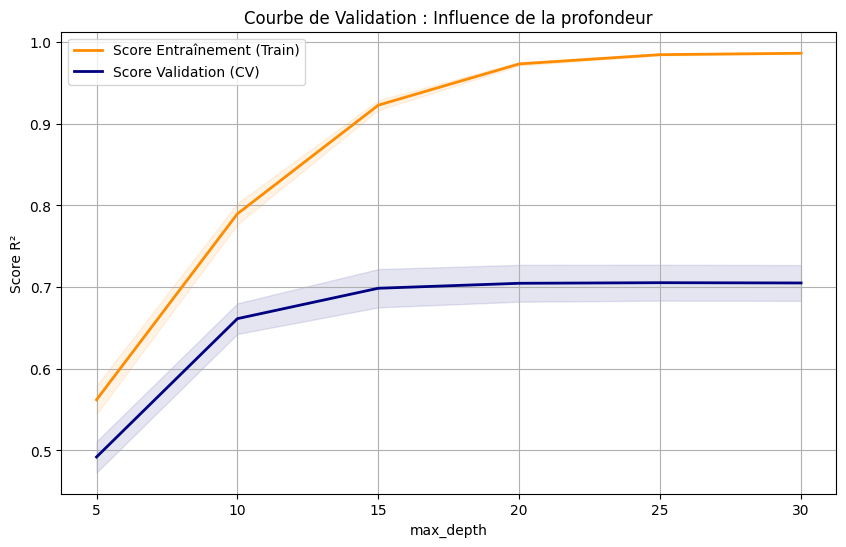

Génération de la courbe pour min_samples_leaf...


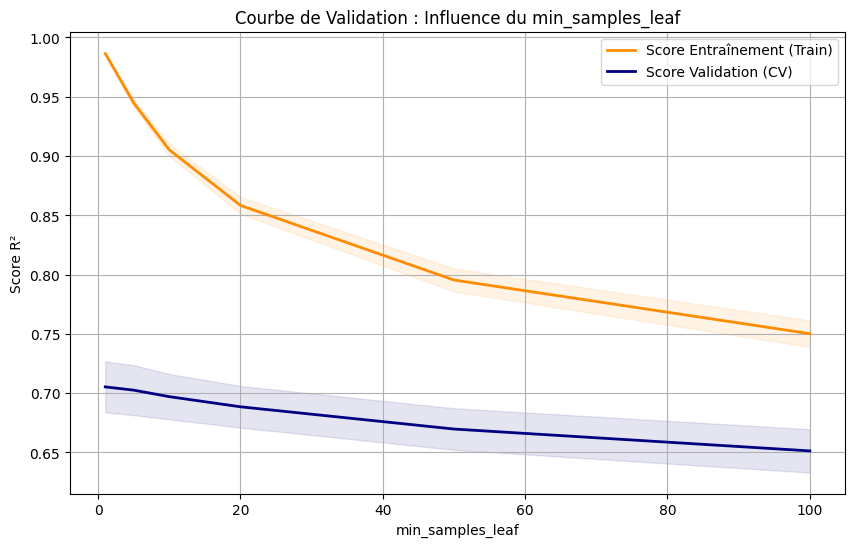

Génération de la courbe pour n_estimators...


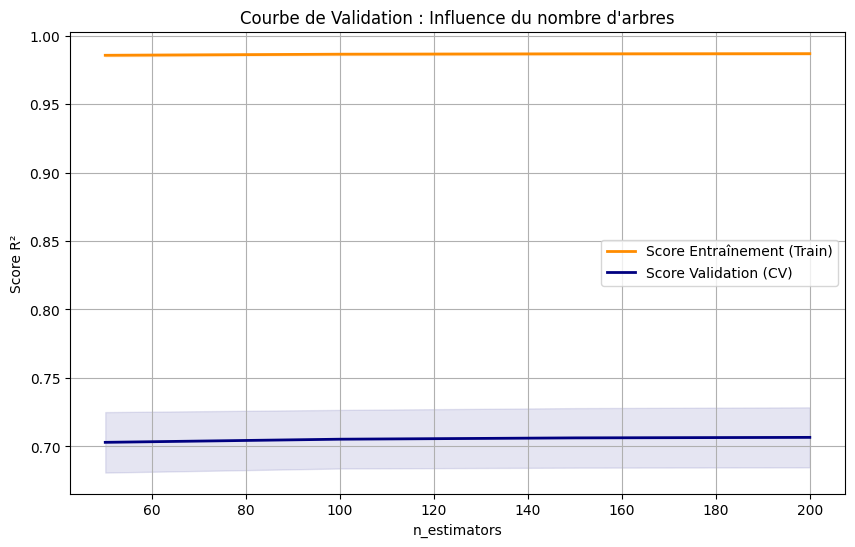

In [ ]:
from sklearn.model_selection import validation_curve
def plot_validation_curve(estimator, X, y, param_name, param_range, title):
    # Calcul des scores (on utilise le R² ici pour la lisibilité)
    train_scores, test_scores = validation_curve(
        estimator, X, y, param_name=param_name, param_range=param_range,
        cv=3, scoring="r2", n_jobs=-1
    )

    # Moyenne et écart-type
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="Score Entraînement (Train)", color="darkorange", lw=2)
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.1, color="darkorange")
    
    plt.plot(param_range, test_mean, label="Score Validation (CV)", color="navy", lw=2)
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.1, color="navy")

    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("Score R²")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# --- UTILISATION ---

# 1. On teste la profondeur (max_depth)
# On fixe les autres à des valeurs raisonnables
rf_temp = RandomForestRegressor(random_state=42, n_jobs=-1)
depth_range = [5, 10, 15, 20, 25, 30]

print("Génération de la courbe pour max_depth...")
plot_validation_curve(rf_temp, X_train, y_train, "max_depth", depth_range, "Courbe de Validation : Influence de la profondeur")

# 2. On teste le lissage (min_samples_leaf)
rf_temp2 = RandomForestRegressor(random_state=42, n_jobs=-1)
leaf_range = [1, 5, 10, 20, 50, 100]

print("Génération de la courbe pour min_samples_leaf...")
plot_validation_curve(rf_temp2, X_train, y_train, "min_samples_leaf", leaf_range, "Courbe de Validation : Influence du min_samples_leaf")

# 3. On teste le nombre d'arbres (n_estimators)
rf_temp2 = RandomForestRegressor(random_state=42, n_jobs=-1)
n_esti = [50, 100, 150]

print("Génération de la courbe pour n_estimators...")
plot_validation_curve(rf_temp2, X_train, y_train, "n_estimators", n_esti, "Courbe de Validation : Influence du nombre d'arbres")

In [6]:
rf = RandomForestRegressor(n_estimators=50, max_depth=15, min_samples_leaf =38 ,random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)
y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = test['flow']

# Métriques finales
mae_val = mean_absolute_error(y_true, y_pred)
mask_non_zero = y_true > 0
mape_val = np.mean(np.abs((y_true[mask_non_zero] - y_pred[mask_non_zero]) / y_true[mask_non_zero]))

print(f"--- RÉSULTATS RANDOM FOREST ---")
print(f"R² train :", rf.score(X_train, y_train))
print(f"R² test :", rf.score(X_test, y_test))
print(f"MAE  : {mae_val/1000:,.4f} k migrants") # On repasse en milliers pour comparer à Raftery
print(f"MAPE : {mape_val:.2%}")

# 6. IMPORTANCE DES VARIABLES
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop 10 des variables les plus prédictives :")
print(importances.head(10))

--- RÉSULTATS RANDOM FOREST ---
R² train : 0.8099701004943205
R² test : 0.7396503784747099
MAE  : 2.2701 k migrants
MAPE : 486.96%

Top 10 des variables les plus prédictives :
log_dist        0.229069
log_pop_o       0.161675
log_IMR_d       0.158094
log_pop_d       0.145050
log_gdpcap_o    0.067443
LB_ij           0.045928
log_LA_d        0.031247
log_PSR_d       0.028033
log_LA_o        0.026108
log_urban_d     0.023450
dtype: float64


Amélioration de l’erreur MAPE d’un facteur 4 par rapport au modèle de gravité (1600 > 470%)
C’est énorme. Le random Forest a bien mieux compris la dynamique du système que le modèle de gravité. C'est beaucoup mieuxaussi pour l'erreur MAE! Avec une moyenne mondiale de migrants de 2 000, on passe d'une erreur MAE de +4000 à une erreur MAE de 1472. Mais cela reste *assez mauvais*, le modèle bayésien hiérarchique développé plus tard permettra de considérablement diminuer cette erreur, on l'espère! 

Néanmoins: le modèle Random Forest prouve ici toute sa puissance. Avec un modèle bayésien hiérarchique bien développé, les auteurs aboutissent finalement à une erreur MAE de 1,200 migrants. Avec notre erreur MAE de 1,472 migrants, on se rapproche! Mais notre erreur MAPE de 471% reste bien supérieure à la leur, qui est de 70% avec le modèle bayésien hiérarchique (Table 1 *Probabilistic forecasts of international bilateral migration flows Nathan G. Welcha, and Adrian E. Raftery*)

Si les modèles linéaires classiques (type Welch & Raftery) peinent à intégrer des variables économiques comme le PIB sans créer d'instabilité, l'utilisation d'algorithmes non-linéaires comme le Random Forest permet de réhabiliter le PIB comme prédicteur majeur, tout en divisant l'erreur de prédiction par trois par rapport *au modèle de gravité*. 

Description des variables économiques :
     log_gdpcap_o  log_gdpcap_d
min      10.84294      10.84294
max      18.52217      18.52217


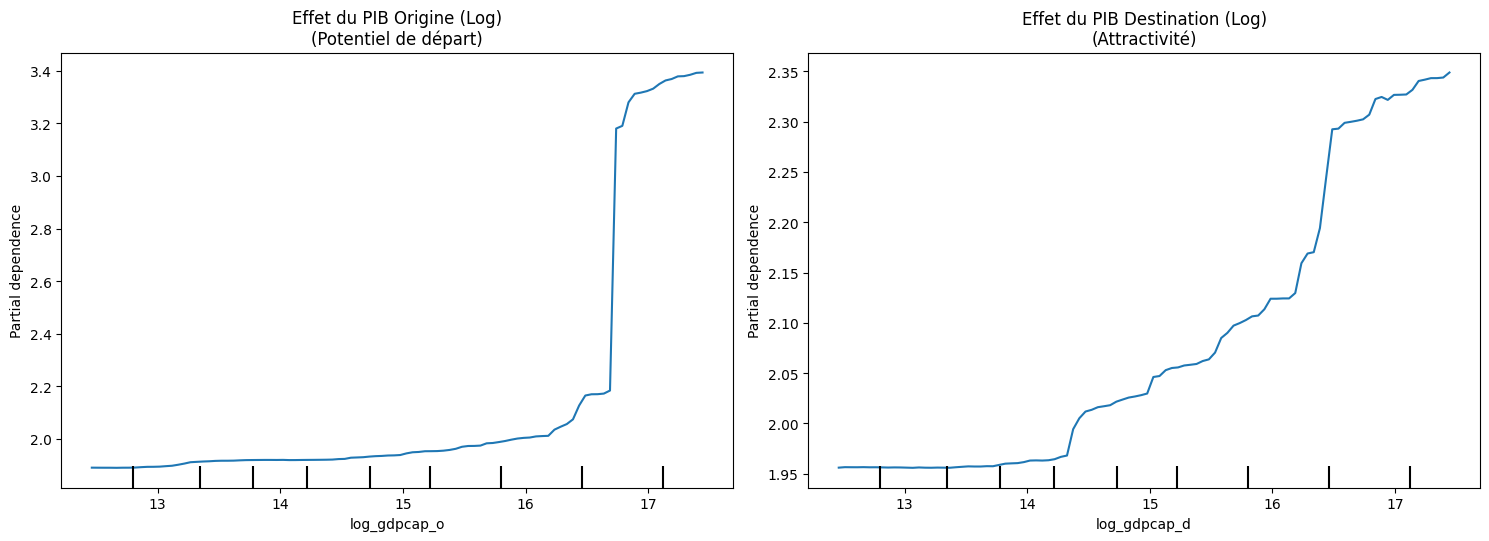

In [14]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay # L'import manquant

# 1. Vérification des noms et de l'étendue
# On s'assure d'utiliser les noms de colonnes exacts de votre dataframe X_train
features_to_plot = ['log_gdpcap_o', 'log_gdpcap_d']
print("Description des variables économiques :")
print(X_train[features_to_plot].describe().loc[['min', 'max']])

# 2. Création du graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Affichage de l'effet du PIB d'origine
PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features=['log_gdpcap_o'], 
    kind="average", 
    percentiles=(0.05, 0.95), # On resserre pour éviter le bruit des extrêmes
    ax=ax1
)
ax1.set_title("Effet du PIB Origine (Log)\n(Potentiel de départ)")
ax1.set_ylabel("Impact sur log(Flow + 1)")
ax1.grid(True, alpha=0.3)

# Affichage de l'effet du PIB destination
PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features=['log_gdpcap_d'], 
    kind="average", 
    percentiles=(0.05, 0.95), 
    ax=ax2
)
ax2.set_title("Effet du PIB Destination (Log)\n(Attractivité)")
ax2.set_ylabel("Impact sur log(Flow + 1)")
ax2.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('pdp_gdp_analysis.png', dpi=300)
plt.show()

Comment cette courbe est tracée:  

Pour chaque pays, on fixe le log du PIB par tête d’origine à une
certaine valeur, puis on calcule la prédiction du log du nombre de migrants. On répète le processus
pour balayer toutes les valeurs possibles de log(gdp_cap_o). C’est une expérience de pensée : que
se passerait il si pour le pays en question, le PIB par tête valait X ? et ce, pour tout X.
Ensuite, on fait la moyenne sur tous les pays pour tracer ce graphique. (C’est le point criticable!
il y a surtout des effets hétérogènes du PIB entre les pays). => c’est pourquoi nous avons l’idée
de diviser la liste des pays en deux, en fixant arbitrairement la limite entre “pays pauvre” et “pays
riche” à 12k$ GDP per capita

Log = -3 : 50$ par habitant. (Extrême pauvreté ou erreur de donnée).  
Log = 2.5 : 12,100$ par habitant. (point de bascule).  
Log = 3.0 : 20 000$ par habitant. (Entrée dans le club des pays occidentaux, c’est le seuil attendu). 
Log = 4.4 : 80 000$ par habitant. (max dans le monde, qatar suisse etc). 


Nouvelles courbes (PDP) en divisant en deux groupes selon le critère >12k$ GDP/capita: 






Le PIB a un impact marginal 6 à 7 fois plus puissant sur les flux migratoires dans les grandes puissances économiques que dans les petites. La "masse" économique (l'effet de gravité pur) ne devient vraiment le moteur ultra-dominant qu'au-delà d'un certain seuil de taille critique du pays.

Il existe clairement un seuil de richesse à partir duquel la migration augmente brusquement. L’effet
du PIB/tete pour les valeurs <= 12k$ est quasi-linéaire et quasi-nul: augmenter légèrement la
richesse chez un pays pauvre n’a PAS d’effet sur la migration. (noter la différence d’échelle entre
les deux graphiques /!!! La courbe rouge évolue sur une gamme très étroite de l’ordonnée, signe que
la courbe est quasi plate. En revanche, la courbe bleue présente une augmentation nette sur une
échelle significative)



**CONCLUSION**. 
Effet de seuil clair et net. Cela valide définitivement l'intérêt d'utiliser le PIB. Attention à l'échelle du premier graphique.

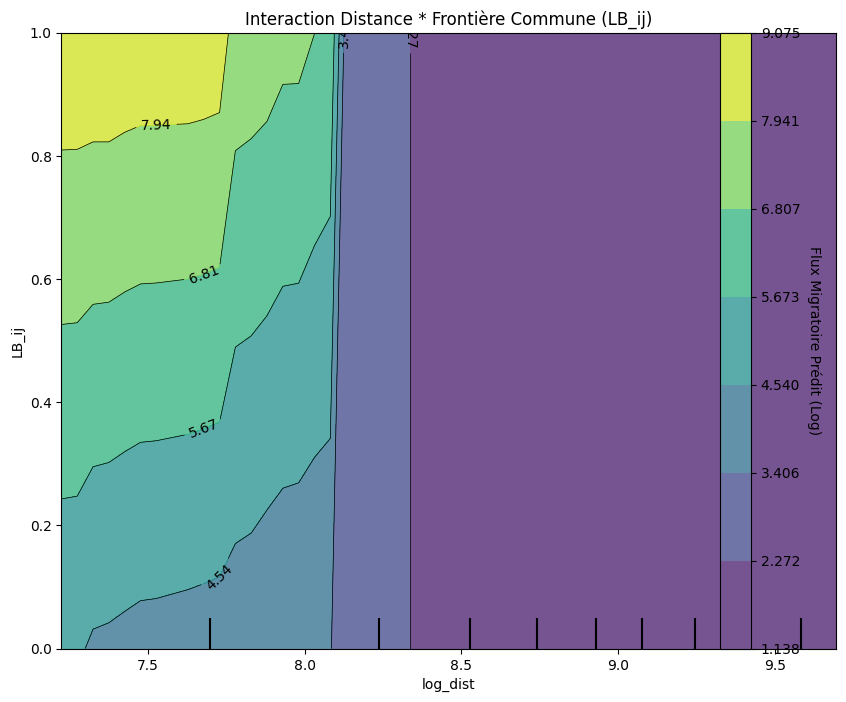

In [9]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 1. Sélection de l'interaction (Distance vs Frontière)
features_inter = [('log_dist', 'LB_ij')] 

# 2. Tracé du graphique
fig, ax = plt.subplots(figsize=(10, 8))

graph = PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features_inter,       
    kind="average", 
    grid_resolution=50, # Pour lisser les courbes
    ax=ax
)

# Ajustement de la barre de couleur (échelle Log)
cbar = fig.colorbar(graph.contours_[0, 0], ax=ax)
cbar.set_label('Flux Migratoire Prédit (Log)', rotation=270, labelpad=15)

plt.title("Interaction Distance * Frontière Commune (LB_ij)")
plt.show()

Interprétation plus délicate, graphe d’un Partial Dependance Plot en 3D: 

on remarque que dans la zone frontière_commune=1 et log_distance faible (en haut à gauche) le nombre de migrant prédit est élevé. Au
contraire, à frontière_commune=0 et log_distance élevée (double peine, mais logique qu’on ne soit pas voisin
si la distance est élevée): le nombre de migrant prédit est beaucoup plus faible. Le gradient de
couleur n’est pas linéaire et vertical de gauche à droite (contrairement au prochain graphe), c’est
le signe que les deux variables contig et distance intéragissent.


Note: ce graphique a pour but de visualiser une possible interaction grossièrement, mais n’est pas
rigoureusement interprétable tel quel puisque la variable contig ne prend que les valeurs 0 et 1 (les
valeurs intermédiaires n’ont pas de sens)

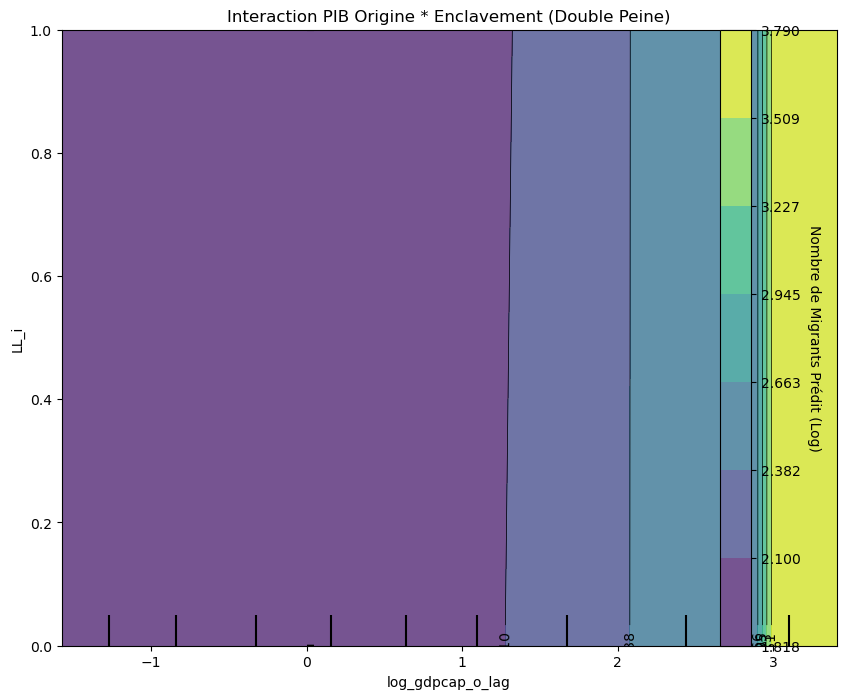

In [20]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 1. Sélection de l'interaction (PIB Origine vs Enclavement Origine)
features_inter = [('log_gdpcap_o_lag', 'LL_i')] 

# 2. Tracé du graphique
fig, ax = plt.subplots(figsize=(10, 8))

graph = PartialDependenceDisplay.from_estimator(
    rf, 
    X_train, 
    features_inter,       
    kind="average", 
    grid_resolution=50,
    ax=ax
)

# Ajustement de la barre de couleur
cbar = fig.colorbar(graph.contours_[0, 0], ax=ax)
cbar.set_label('Nombre de Migrants Prédit (Log)', rotation=270, labelpad=15)

plt.title("Interaction PIB Origine * Enclavement (Double Peine)")
# Note : J'ai commenté xlim car tes logs de PIB sont probablement entre 6 et 11
# plt.xlim(0, 4.4) 
plt.show()

Ici, nous n’avons pas de preuve forte pour une interaction entre la variable “landlocked” et “log
richesse”: le gradient de couleur est plutôt linéaire et vertical de gauche à droite (la valeur de la
prédiction de migrant pour une abscisse donnée n’est pas corrélée à la valeur de l’ordonnée)

In [11]:
pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 98.0 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 79.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


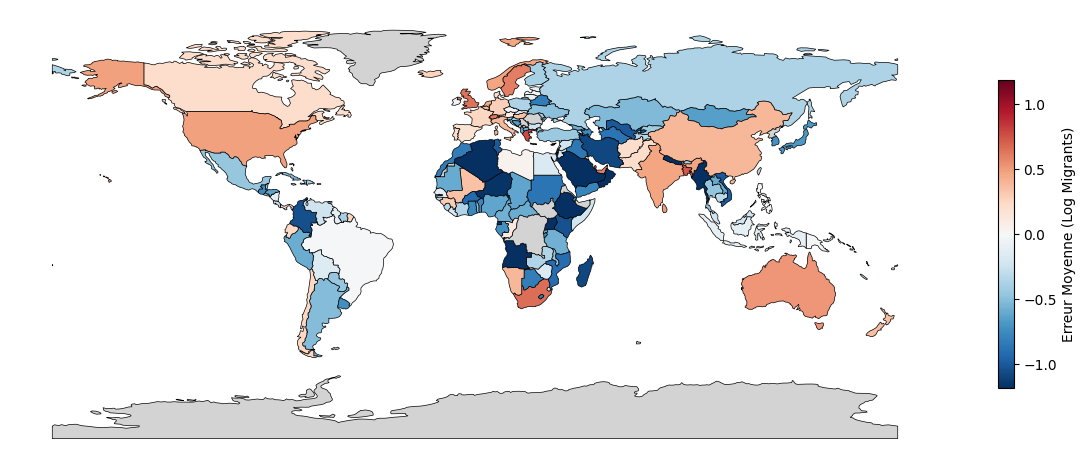

In [ ]:
# Carte des Résidus 
import geopandas as gpd

# 1) Calcul des résidus
test['residuals'] = test['log_target'] - rf.predict(X_test)
resid_by_country = test.groupby('orig')['residuals'].mean().reset_index()

# 2) Chargement du fond de carte (url directe natural earth)

url_world = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_world)

# 3) Harmonisation des codes ISO (Natural Earth utilise souvent 'ADM0_A3' ou 'ISO_A3')
# On s'assure d'avoir une colonne 'iso_a3' minuscule pour votre fusion
col_iso = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'
world['iso_a3'] = world[col_iso]

# 4) Fusion
world_map = world.merge(resid_by_country, left_on='iso_a3', right_on='orig', how='left')

# 5) Vizu
v_max = world_map['residuals'].abs().quantile(0.95)

fig, ax = plt.subplots(figsize=(15, 8))
world_map.plot(
    column='residuals', 
    cmap='RdBu_r', 
    linewidth=0.5,
    edgecolor='black',
    ax=ax, 
    legend=True,
    vmin=-v_max, 
    vmax=v_max,
    missing_kwds={'color': 'lightgrey', 'label': 'Pas de données'},
    legend_kwds={'label': "Erreur Moyenne (Log Migrants)", 'shrink': 0.5}
)
ax.set_title(f"Carte des Résidus d'Émigration (Test 2015) - Saturée à +/- {v_max:.2f}", fontsize=14)
ax.axis('off')
plt.show()

Une erreur de $1.33$ en log signifie que le Random Forest se trompe en moyenne d'un facteur de $e^{1.33} \approx 3.78$. 
En gros, pour les 5% des pays où il est le moins bon, il prédit presque 4 fois plus (ou 4 fois moins) de migrants que la réalité.


Il y a un Biais de sélection clair si les flux=0 sont arbitrairement supprimés: le modèle sur-estime les zones de petits flux. 
Voir QR Code (matrice adjacente, data_final/.png). On voit les "bons" pays, et ceux qui se comportent moins bien dans les données. 

Si l'Afrique est en bleue sauf gros hubs comme Nigeria/AFS ; et iles du Pacifique, c'est une preuve très solide pour justifier l'incorporation des flux nuls pour la robustesse scientifique (biais de sélection évident sinon).


**Commentaires** sur cette carte des résidus de la prédiction en 2015: 

Même avec l'ajout des flux nuls dans les données, les flux migratoires de certains pays restent sur-esimés. On gagne néanmoins en précision sur des hubs migratoires importants (Etats Unis, Europe, Afrique du Sud, Inde et Chine). 
On pense très fortement à l'ajout de variables omises comme les barrières légales à la migration (voir analyse de l'ancienne carte sur la prédiction 2010 ci-dessous) et des variables politiques (est ce que le pays est une dictature? cela peut corriger la surestimation du Myanmar par exemple). 
  




**Commentaire** sur la carte des résidus en supprimant les flux=0, avec prédiction en 2010 (n'est ***plus d'actualité***, on a corrigé le biais de sélection que la suppression des flux=0 causait, et nous sommes passé à la prédiction sur 2015).


ZONES BLEUES (le modèle sur-estime les flux "réels")



- Niger Tchad Burkina Faso RépCentrafricaine: TRAPPE A PAUVRETé que le modèle a réussi à capter (cf courbe à seuil pour gdpcap_o), mais il en sous estime encore la puissance (il prédit un plus faible nombre de migrants, alors qu'en réalité ce nombre est vraiment proche du néant)

- Arabie Saoudite : le modèle voit un pays riche et connecté à l'international, il prédit une migration comparable aux pays occidentaux. En réalité, le pays est stabilisé par sa "rente pétrolière" qui achète et sédentarise les nationaux. 

- Chili : isolement géographique par les Andes ? stabilité culturelle, nationaux attachés peut être ? 

- Myanmar: dictature qui ferme le pays en 2010. 

- madagascar: combinaison de la trappe à pauvreté avec l'isolement insulaire, les billets d'avions sont infiniment chers pour les locaux.

- Algérie : le modèle capte la proxmité coloniale, mais en réalité l'obtention d'un visa Schenghen refroidit le potentiel de proximité coloniale. Le désir de migrer est là, la possiblité  légale l'est moins.

- Kazakhstan: le modèle a appris sur le départ des soviétiques après la chute de l'URSS en 90-2000, et a anticipté des trop gros flux en 2010 alors que l'économie s'était stabilisée. 



ZONES ROUGES (le modèle sous-estime les flux "réels")



- Libye: problème ici ? khadafi règnait jusqu'en 2011 et fermait le pays. 

- Israel : diaspora, israeliens ont souvent double nationalité, circulent facilement, hyper-mobilité que le modèle n'a pas capté.

- Rép du Congo Brazzaville: plus stable que le Congo Kinshasa, assez pauvre mais avec liens coloniaux français plus forts que le modèle pensait (variable gdpcap * dummy liens coloniaux ? )
Le modèle prédit bien pour Congo belge.

- Afrique du Sud: pays du BRICS très émergent, le modèle prévoit une stabilité et sédentarité. Or la criminalité assez fortement tjr présente pousse les classes moyennes/supérieures à fuir 




# Explication simple du XGBoost: 

Le Random Forest construit tous ses arbres en même temps, de façon indépendante. Le XGBoost, lui, fonctionne comme un joueur de golf. Le premier arbre fait un 'swing' et envoie la balle (la prédiction) quelque part sur le terrain. Il regarde la distance qui lui reste jusqu'au trou (l'erreur de prédiction). Le deuxième arbre ne va pas essayer de rejouer le premier coup : il va taper la balle depuis l'endroit où elle a atterri pour la rapprocher du trou. Le troisième arbre corrigera les petits millimètres restants. Dans notre projet, le XGBoost est redoutable car il va cibler en priorité les routes migratoires que les modèles précédents n'arrivaient pas à expliquer (les gros résidus).

In [25]:
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

# 1. PRÉPARATION (Identique au Random Forest)
df_ml = df_main.copy()

log_map = {
    'P_it': 'log_pop_o', 'P_jt': 'log_pop_d', 'D_ij': 'log_dist',
    'PSR_i': 'log_PSR_o', 'PSR_j': 'log_PSR_d',
    'IMR_it': 'log_IMR_o', 'IMR_jt': 'log_IMR_d',
    'urban_it': 'log_urban_o', 'urban_jt': 'log_urban_d',
    'LA_i': 'log_LA_o', 'LA_j': 'log_LA_d'
}
for col, new_col in log_map.items():
    df_ml[new_col] = np.log(df_ml[col].replace(0, np.nan))

df_ml['log_target'] = np.log1p(df_ml['flow'])

features = list(log_map.values()) + [
    'LL_i', 'LL_j', 'LB_ij', 'OL_ij', 'COL_ij', 
    't_2000', 't_2000_sq', 'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]

df_ml = df_ml.dropna(subset=features + ['log_target']).copy()

# 2. SPLIT TEMPOREL
train = df_ml[df_ml['year'] < 2015]
test  = df_ml[df_ml['year'] == 2015]

X_train, y_train = train[features], train['log_target']
X_test, y_test   = test[features], test['log_target']

# 3. ENTRAÎNEMENT DU XGBOOST
# max_depth=6 est souvent le "sweet spot" pour XGBoost (plus bas que RF)
# learning_rate=0.1 contrôle la vitesse à laquelle il corrige ses erreurs
xgb_model = xgb.XGBRegressor(
    n_estimators=200, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42, 
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# 4. PRÉDICTION ET ÉVALUATION
y_pred_log = xgb_model.predict(X_test)
y_pred = np.expm1(y_pred_log) # Retour à l'échelle réelle
y_true = test['flow']

# Calcul des erreurs
mae = mean_absolute_error(y_true, y_pred)
mask = y_true > 0
mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask])

print(f"RÉSULTATS XGBOOST (Test 2015)")
#print(f"R² (Log-Scale) : {r2_score(y_test, y_pred_log):.4f}")
print(f"MAE  : {mae:,.0f} migrants")
print(f"MAPE : {mape:.2%}")

# 5. IMPORTANCE DES VARIABLES (Poids dans le modèle)
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)
print("\nTop  des variables XGBoost :")
print(importances.head(10))

RÉSULTATS XGBOOST (Test 2015)
MAE  : 1,949 migrants
MAPE : 413.74%

Top  des variables XGBoost :
LB_ij               0.240083
log_IMR_d           0.107842
COL_ij              0.099555
log_dist            0.066656
log_pop_o           0.064275
log_pop_d           0.061171
OL_ij               0.051840
log_gdpcap_o_lag    0.046387
log_PSR_d           0.039491
log_gdpcap_d_lag    0.033852
dtype: float32


/var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/ipykernel_9868/1387490246.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['residuals_xgb'] = test['log_target'] - xgb_model.predict(X_test)


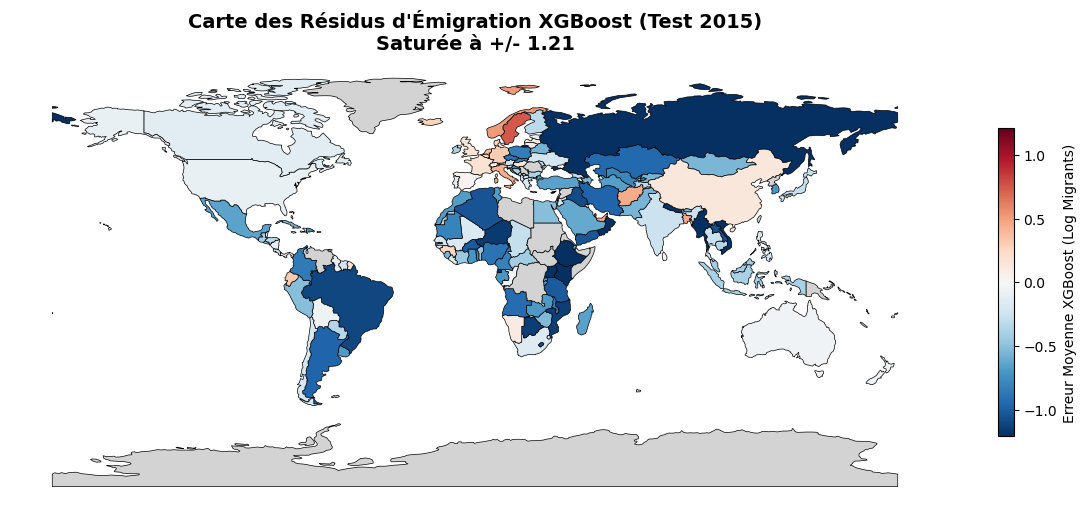

In [26]:


# 1) Calcul des résidus (Vraie valeur log - Prédiction log)
test['residuals_xgb'] = test['log_target'] - xgb_model.predict(X_test)

# On fait la moyenne des erreurs par pays d'origine (émigration)
resid_by_country_xgb = test.groupby('orig')['residuals_xgb'].mean().reset_index()

# 2) Chargement du fond de carte (Natural Earth)
url_world = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_world)

# 3) Harmonisation des codes ISO
col_iso = 'ADM0_A3' if 'ADM0_A3' in world.columns else 'ISO_A3'
world['iso_a3'] = world[col_iso]

# 4) Fusion des données géographiques et de nos résidus
world_map_xgb = world.merge(resid_by_country_xgb, left_on='iso_a3', right_on='orig', how='left')

# 5) Visualisation
# On sature à 95% pour éviter que les valeurs extrêmes n'écrasent la palette de couleurs
v_max = world_map_xgb['residuals_xgb'].abs().quantile(0.95)

fig, ax = plt.subplots(figsize=(15, 8))
world_map_xgb.plot(
    column='residuals_xgb', 
    cmap='RdBu_r', 
    linewidth=0.5,
    edgecolor='black',
    ax=ax, 
    legend=True,
    vmin=-v_max, 
    vmax=v_max,
    missing_kwds={'color': 'lightgrey', 'label': 'Pas de données'},
    legend_kwds={'label': "Erreur Moyenne XGBoost (Log Migrants)", 'shrink': 0.5}
)
ax.set_title(f"Carte des Résidus d'Émigration XGBoost (Test 2015)\nSaturée à +/- {v_max:.2f}", fontsize=14, fontweight='bold')
ax.axis('off')
plt.show()

Une erreur de $1.33$ en log signifie que le Random Forest se trompe en moyenne d'un facteur de $e^{1.33} \approx 3.78$. 
En gros, pour les 5% des pays où il est le moins bon, il prédit presque 4 fois plus (ou 4 fois moins) de migrants que la réalité.

Une erreur de $1.21$ en log signifie que le XGBoost se trompe d'un facteur de $e^{1.21} \approx 3.35$.





***Micro-étape:*** 
$$P(\theta_i | \theta_{-i}, Data) \propto P(Data | \theta_i, \theta_{-i}) \times P(\theta_i)$$

Si on prend le paramètre $\mu_c$ (taux d'équilibre) pour la France par exemple :   
- L'algorithme fige le $\phi_c$ et le $\sigma_c^2$ de la France, ainsi que les hyperparamètres globaux $\lambda$ et $\tau^2$.  
- Il regarde les données historiques de la France via l'équation autorégressive $AR(1)$ : $(r_{c,t} - \mu_c) = \phi_c (r_{c,t-1} - \mu_c) + \epsilon_{c,t}$. C'est la vraisemblance.  
- Il regarde d'où est censé venir ce $\mu_c$ selon le modèle hiérarchique : $\mu_c \sim N(\lambda, \tau^2)$. C'est le Prior.  
- Il multiplie les deux, obtient une nouvelle courbe de probabilité, et tire une nouvelle valeur de $\mu_c$ au hasard dans cette courbe.

***Macro-étape:***

1) Boucle sur les $\approx 200$ pays (Niveau 2) :  
- Pour chaque pays $c$, on met à jour $\mu_c$ (sachant $\lambda$, $\tau^2$, et les autres paramètres fixés).  
- On met à jour $\phi_c$ (sachant qu'il vient d'un Prior uniforme $U(0,1)$).  
- On met à jour la variance de l'erreur $\sigma_c^2$ (sachant qu'elle vient d'un Prior Inverse Gamma $IG(a,b)$).  

2) Mise à jour des Hyperparamètres globaux (Niveau 3) :

- Maintenant que les 200 $\mu_c$ ont bougé, l'algorithme "remonte" d'un niveau. Il utilise ces 200 nouveaux $\mu_c$ comme si c'était des données pour mettre à jour la moyenne globale $\lambda$ et la variance globale $\tau$.
- De même, il utilise les 200 nouvelles variances $\sigma_c^2$ pour mettre à jour les hyperparamètres $a$ et $b$.


Une fois une macro-étape terminée, on a généré ***un point***. On répète des milliers de fois, on a un tableau, on en fait ensuite la moyenne, intervalles de confiance, prédiction décennies après décennies. 

Loi initiale pas importante (théorème ergodique). 
Irréductibilité: loi normale jamais vraiment =0. 
Apériodique: proba non nulle de rester dans la même zone, PGCD=1. 
Récurrente positive: Priors propres 



# Apports du RandomForest et XGBoost 

Ces modèles simples de Machine Learning nous ont donné les idées suivantes: 

- clusteriser les zones géographiques (on a remarqué que l'on sur-estimait les flux en Afrique, car ils sont souvent trop faibles et nos modèles peinent à prédire précisemment les flux faibles).
- ajouter des variables omises (variables politiques comme la présence d'une dictacture, cf la sur-estimation des migrations au Myanmar; variables légales comme la barrière à l'obtention de visas.)
- considérer un effet de seuil sur le PIB; ajouter une variable couplant l'effet de la distance et si oui ou non deux pays i et j partagent une frontière commune; 
- ...

On améliore ainsi le modèle AR(1) de Welch et Raftery en incluant ces observations dans les variables X du modèle suivant: 


$$r_{c,t} - X_{c,t}\beta = \phi_c (r_{c,t-1} - X_{c,t-1}\beta) + \epsilon_{c,t}$$

avec donc X contenant les déterminants économiques et démographiques. 

Aussi, augmenter la variance des Priors dans les zones où nos modèles se trompent le plus: 

$\sigma_{c}^2 \sim IG(a_{region}, b_{region})$ 


**Importance des variables (XGBoost et RF):** plutôt que d'utiliser des priors aléatoires, guider plus précisement le Gibbs Sampler avec ces infos. Convergence plus rapide, et on peut éviter les états métastables?



# TROISIEME PARTIE: 

Début d'implémentation du modèle bayésien hiérarchique (modèle final). Le Machine Learning permet de détecter les effets non-linéaires que les auteurs ont manqué, et qu'il faudra intégrer dans ce modèle bayésien final, pour augmenter la qualité des prédictions. 

Les modèles de Machine Learning (RF, XGBoost) montrent leurs limites sur les données africaines ou instables, car ils n'intègrent pas l'incertitude fondamentale des données de flux. C'est précisément pour répondre à ce problème que nous allons introduire les méthodes bayésiennes (MCMC). Contrairement au XGBoost qui crache une prédiction 'sèche', les méthodes de Monte-Carlo vont nous permettre de modéliser l'incertitude (les priors) et de générer des intervalles de confiance robustes pour ces couloirs migratoires complexes.

In [6]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185578 entries, 0 to 185577
Data columns (total 44 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   orig              185578 non-null  object 
 1   dest              185578 non-null  object 
 2   iso3_d            185578 non-null  int64  
 3   year              185578 non-null  int64  
 4   iso3_o            185578 non-null  int64  
 5   flow              185578 non-null  int64  
 6   P_it              182034 non-null  float64
 7   PSR_i             182034 non-null  float64
 8   IMR_it            182034 non-null  float64
 9   urban_it          182034 non-null  float64
 10  LA_i              182034 non-null  float64
 11  LL_i              182034 non-null  float64
 12  P_jt              182034 non-null  float64
 13  PSR_j             182034 non-null  float64
 14  IMR_jt            182034 non-null  float64
 15  urban_jt          182034 non-null  float64
 16  LA_j              18

In [ ]:

# TESTS

# A. Modèle Hurdle pour is_migration_t

import statsmodels.formula.api as smf

# 1. Préparation (on s'assure d'avoir le lag)
df_test_A = df_main.sort_values(['orig', 'dest', 'year']).copy()
df_test_A['is_mig_lag'] = df_test_A.groupby(['orig', 'dest'])['is_migration'].shift(1)
df_test_A = df_test_A.dropna(subset=['is_mig_lag', 'D_ij', 'LB_ij'])

# 2. Régression Logistique avec statsmodels (le '*' crée automatiquement l'interaction !)
modele_logit = smf.logit(formula="is_migration ~ is_mig_lag + D_ij * LB_ij", data=df_test_A).fit()

# 3. Affichage des p-values et coefficients
print(modele_logit.summary())




Optimization terminated successfully.
         Current function value: 0.292581
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:           is_migration   No. Observations:               145324
Model:                          Logit   Df Residuals:                   145319
Method:                           MLE   Df Model:                            4
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.5771
Time:                        13:46:26   Log-Likelihood:                -42519.
converged:                       True   LL-Null:                   -1.0055e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.5238      0.022    -69.240      0.000      -1.567      -1.481
is_mig_lag     4.5300      0

In [11]:


# B. modèle hiérarchique AR(X) 

df_test_B = df_main.copy()
# 1. Le PIB de base (la pente pour les pays pauvres)
df_test_B['log_gdpcap_o_lag'] = df_test_B['log_gdpcap_o_lag']

# 2. L'indicatrice de richesse (le bouton on/off)
# Vaut 1 si le pays a franchi le seuil, 0 sinon
df_test_B['is_rich_o'] = (df_test_B['log_gdpcap_o_lag'] > 2.9).astype(int)

# 3. L'interaction (la pente de correction pour les pays riches)
df_test_B['gdp_rich_interaction'] = df_test_B['log_gdpcap_o_lag'] * df_test_B['is_rich_o']

import statsmodels.formula.api as smf
import numpy as np

# 1. On filtre pour ne garder que l'univers du "Volume" (flux > 0)
df_volume_test = df_test_B[df_test_B['flow'] > 0].copy()

# 2. On recrée proprement la cible (le logarithme pur) et le lag temporel
df_volume_test['log_flow'] = np.log(df_volume_test['flow'])

# On trie bien pour que le shift(1) prenne l'année précédente du même couloir
df_volume_test = df_volume_test.sort_values(by=['orig', 'dest', 'year'])
df_volume_test['log_flow_lag'] = df_volume_test.groupby(['orig', 'dest'])['log_flow'].shift(1)

# 3. On nettoie les valeurs manquantes (les années 1990 qui n'ont pas de lag, et les PIB manquants)
df_clean_B = df_volume_test.dropna(subset=[
    'log_flow_lag', 'log_gdpcap_o_lag', 'is_rich_o', 'gdp_rich_interaction'
])

# 4. Lancement de la régression linéaire classique (OLS)
# On retire gdp_rich_interaction de la formule
formule_C = "log_flow ~ log_flow_lag + log_gdpcap_o_lag + is_rich_o"
modele_ols_2 = smf.ols(formula=formule_C, data=df_clean_B).fit()

print(modele_ols_2.summary())





                            OLS Regression Results                            
Dep. Variable:               log_flow   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                 1.412e+05
Date:                Tue, 10 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:05:59   Log-Likelihood:            -1.1317e+05
No. Observations:               73310   AIC:                         2.264e+05
Df Residuals:                   73306   BIC:                         2.264e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3640      0.008  

In [ ]:
import pycountry_convert as pc
import numpy as np


# C. Clusters géographiques 



def get_continent_id(iso3_code):
    try:
        # 1. Convertir ISO3 (ex: 'FRA') en ISO2 (ex: 'FR')
        iso2 = pc.country_alpha3_to_country_alpha2(iso3_code)
        # 2. Convertir ISO2 en code Continent (ex: 'EU')
        continent = pc.country_alpha2_to_continent_code(iso2)
        
        # 3. Mapper les continents vers des entiers pour Stan (1 à 6)
        mapping = {
            'EU': 1, # Europe
            'NA': 2, # North America
            'AF': 3, # Africa
            'SA': 4, # South America
            'AS': 5, # Asia
            'OC': 6  # Oceania
        }
        return mapping.get(continent, 7) # 7 pour "Inconnu" au cas où
    except:
        # Si un code ISO est bizarre (ex: 'ROM' au lieu de 'ROU')
        return 7 

# Appliquer la fonction sur la colonne d'origine
df_main['cluster_orig_id'] = df_main['orig'].apply(get_continent_id)

# Petit check pour voir si la répartition a bien marché :
print(df_main['cluster_orig_id'].value_counts())

cluster_orig_id
3    53268
5    46564
1    37386
2    23664
4    12436
6    11897
7      363
Name: count, dtype: int64


In [9]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185578 entries, 0 to 185577
Data columns (total 45 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   orig              185578 non-null  object 
 1   dest              185578 non-null  object 
 2   iso3_d            185578 non-null  int64  
 3   year              185578 non-null  int64  
 4   iso3_o            185578 non-null  int64  
 5   flow              185578 non-null  int64  
 6   P_it              182034 non-null  float64
 7   PSR_i             182034 non-null  float64
 8   IMR_it            182034 non-null  float64
 9   urban_it          182034 non-null  float64
 10  LA_i              182034 non-null  float64
 11  LL_i              182034 non-null  float64
 12  P_jt              182034 non-null  float64
 13  PSR_j             182034 non-null  float64
 14  IMR_jt            182034 non-null  float64
 15  urban_jt          182034 non-null  float64
 16  LA_j              18

In [18]:
import cmdstanpy
cmdstanpy.rebuild_cmdstan()

 (00:00) |            | Building CmdStan                     

In [20]:
# premier modèle AR(1), sanity check 

import pandas as pd
import numpy as np
from cmdstanpy import CmdStanModel

# 1. Sélection de nos 11 pays "crash-test" (Codes ISO3 à vérifier selon ta base)
pays_test = ['DZA', 'MMR', 'RWA', 'HTI', 'ZAF', 'NER', 'FRA', 'USA', 'ESP', 'CAN', 'MEX']

# On filtre la base pour ne garder QUE les flux entre ces 11 pays (soit 110 couloirs max)
df_step1 = df_main[(df_main['orig'].isin(pays_test)) & (df_main['dest'].isin(pays_test))].copy()

# 2. Création de l'identifiant unique de Dyade (Stan a besoin d'entiers de 1 à D)
df_step1['dyad'] = df_step1['orig'] + "_" + df_step1['dest']
dyades_uniques = df_step1['dyad'].unique()

# On crée un dictionnaire pour mapper "DZA_FRA" -> 1, "RWA_ZAF" -> 2, etc.
dyad_map = {dyad: i+1 for i, dyad in enumerate(dyades_uniques)}
df_step1['dyad_id'] = df_step1['dyad'].map(dyad_map)

# 3. Création de la cible (log_y) et du retard temporel (log_y_lag)
# On trie bien par dyade puis par année pour que le shift(1) prenne bien le (t-1)
df_step1 = df_step1.sort_values(by=['dyad', 'year'])
df_step1['log_y'] = np.log1p(df_step1['flow'])
df_step1['log_y_lag'] = df_step1.groupby('dyad')['log_y'].shift(1)

# Le shift crée un NaN pour la toute première année de chaque dyade, on doit les enlever
df_stan = df_step1.dropna(subset=['log_y_lag']).copy()

# 4. Préparation du dictionnaire de données pour Stan (doit matcher le bloc data {})
stan_data = {
    'N': len(df_stan),
    'D': len(dyades_uniques),
    'dyad_id': df_stan['dyad_id'].astype(int).tolist(),
    'log_y': df_stan['log_y'].values.tolist(),
    'log_y_lag': df_stan['log_y_lag'].values.tolist()
}

# 5. Compilation et Lancement du Gibbs/NUTS
print(f"Lancement de Stan sur {stan_data['N']} observations et {stan_data['D']} dyades...")
model = CmdStanModel(stan_file='../STAN/MCMC_AR1.stan')

fit = model.sample(
    data=stan_data, 
    chains=4, 
    parallel_chains=4, 
    iter_warmup=500,    
    iter_sampling=1000,
    seed=42 # Toujours mettre une seed en bayésien pour la reproductibilité !
)

# 6. Vérification du Sanity Check
resume = fit.summary()
print("\n--- Résumé des Hyperparamètres Globaux ---")
print(resume.loc[['mu_global', 'sigma_mu']])

15:24:38 - cmdstanpy - INFO - compiling stan file /var/folders/47/r5kv9z4j6kg1sk0dvr2l5ydh0000gn/T/tmp4e2zgzyo/tmp07i72iwh.stan to exe file /Users/romain/Desktop/Projets DS/ProjetStat/STAN/MCMC_AR1


Lancement de Stan sur 530 observations et 110 dyades...


15:24:47 - cmdstanpy - INFO - compiled model executable: /Users/romain/Desktop/Projets DS/ProjetStat/STAN/MCMC_AR1
15:24:48 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

15:27:08 - cmdstanpy - INFO - CmdStan done processing.
15:27:08 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter is -inf, but must be finite! (in 'MCMC_AR1.stan', line 39, column 4 to column 100)
Consider re-running with show_console=True if the above output is unclear!


15:27:08 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 132 divergent transitions (13.2%)
	Chain 1 had 867 iterations at max treedepth (86.7%)
	Chain 2 had 999 iterations at max treedepth (99.9%)
	Chain 3 had 91 divergent transitions (9.1%)
	Chain 3 had 908 iterations at max treedepth (90.8%)
	Chain 4 had 134 divergent transitions (13.4%)
	Chain 4 had 865 iterations at max treedepth (86.5%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



--- Résumé des Hyperparamètres Globaux ---
               Mean      MCSE    StdDev       MAD            5%       50%  \
mu_global  0.752900  0.644165  0.912386  0.562857  9.614580e-07  0.379641   
sigma_mu   0.537179  0.463337  0.656261  0.391397  3.187450e-06  0.263996   

               95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
mu_global  2.24737   4.46973    2000.0    0.011652  3.23281  
sigma_mu   1.61599   4.47024    2000.0    0.011653  3.27980  


In [ ]:
import numpy as np
from cmdstanpy import CmdStanModel

# 1. Liste des variables (features) mise à jour
features = [
    'log_pop_o', 'log_pop_d', 'log_dist', 
    'log_PSR_o', 'log_PSR_d', 'log_IMR_o', 'log_IMR_d',
    'log_urban_o', 'log_urban_d', 'log_LA_o', 'log_LA_d',
    'LL_i', 'LL_j', 
    'LB_ij', 'OL_ij', 'COL_ij', 
    't_2000', 't_2000_sq', 
    'log_gdpcap_o_lag', 'log_gdpcap_d_lag'
]

# 2. Préparation des données pour Stan (Dictionnaire de matrices)
# On utilise 'train' (issu du split précédent) et 'log_target' (notre log(1+flow))
stan_data = {
    'N': len(train),
    'K': len(features),
    'X': train[features].values, 
    'y': train['log_target'].values
}

# 3. Compilation et Échantillonnage MCMC
# Assure-toi que le fichier 'MCMC.stan' est bien dans ton dossier de travail
model = CmdStanModel(stan_file='/Users/romain/Desktop/Projets DS/ProjetStat/STAN/MCMC.stan')

# Lancement des 4 chaînes MCMC
fit = model.sample(
    data=stan_data, 
    chains=4, 
    parallel_chains=4, 
    iter_warmup=500,    # Phase d'adaptation
    iter_sampling=1000  # Phase de tirage
)

# 4. Affichage du résumé statistique (Moyenne, Écart-type, R-hat)
print(fit.summary().head(15)) # Affiche les premiers paramètres (souvent les bêtas)

15:06:38 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

15:06:47 - cmdstanpy - ERROR - Chain [3] error: code '-2' Unknown error: -2
15:06:47 - cmdstanpy - ERROR - Chain [1] error: code '-2' Unknown error: -2
15:06:47 - cmdstanpy - ERROR - Chain [2] error: code '-2' Unknown error: -2
15:06:47 - cmdstanpy - ERROR - Chain [4] error: code '-2' Unknown error: -2


KeyboardInterrupt: 

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, mean_absolute_error

# 1. Extraction des simulations (Posterior)
# Stan stocke les paramètres sous forme de vecteurs/matrices
alpha_samples = fit.stan_variable('alpha')  # L'intercept
beta_samples  = fit.stan_variable('beta')   # Les coefficients des features

# 2. Préparation des données de Test
X_test_matrix = test[features].values
y_true_real = np.expm1(test['log_target']) # Retour aux vrais migrants (exp(x)-1)

# 3. Calcul de la distribution prédictive
# Pour chaque simulation, on calcule X * beta + alpha
# Cela crée une matrice (N_test, 4000)
y_log_pred_samples = alpha_samples + np.dot(X_test_matrix, beta_samples.T)

# 4. Agrégation : Moyenne des prédictions
# On fait la moyenne des simulations en échelle log, puis on transforme
y_pred_real = np.expm1(y_log_pred_samples.mean(axis=1))

# 5. Calcul des erreurs
mse_bayes  = mean_squared_error(y_true_real, y_pred_real)
mae_bayes  = mean_absolute_error(y_true_real, y_pred_real)

# Filtrage pour le MAPE (flux > 0 uniquement)
mask = y_true_real > 0
mape_bayes = mean_absolute_percentage_error(y_true_real[mask], y_pred_real[mask])

print(f"--- RÉSULTATS BAYÉSIENS (Test 2015) ---")
print(f"MAE  : {mae_bayes:,.0f} migrants")
print(f"MSE  : {mse_bayes:,.0f}")
print(f"MAPE : {mape_bayes:.2%}")

RÉSULTATS STAN (Test sur 2010 ) 
MSE  : 19,841,685,983
MAPE : 744.63%


Toute première simulation en STAN, ce modèle ultra-basique ne constitue qu'une prise en main du langage STAN.

NOTES DE REUNION 4 Février : PROJET FLUX MIGRATOIRES 

1. TRAITEMENT DES DONNEES ET STATISTIQUES DESCRIPTIVES

L'identification précise des pays outliers potentiels est une priorité, avec une attention particulière pour le Mexique et les États-Unis. L'objectif technique consiste à inférer les données manquantes si le calendrier le permet, tout en documentant systématiquement le biais de sélection dans le rapport final. Il convient de comparer le décile supérieur des pays riches au décile le plus bas en pourcentage, un résultat surprenant mais validé par les premières observations. Enfin, une révision des statistiques descriptives et de la corrélation temporelle du taux de départ est nécessaire.

Le projet s'appuie sur le modèle AR(1) de Welch et Raftery pour rendre compte de la dynamique des séries temporelles:

$$\log(\delta_{it}) = \mu(1-\phi) + \phi \log(\delta_{it-1}) + \epsilon$$

2. MODELISATION ET AMELIORATION DU MAPE

L'étape suivante consiste à tester XGBoost via Scikit-learn en approche "boîte noire" afin de comparer les scores MAPE avec les résultats obtenus par Random Forest. Pour affiner les prédictions, le jeu de données sera segmenté, notamment via la variable de contiguïté. L'utilisation de variables indicatrices permettra de capturer des seuils de rupture non linéaires identifiés lors des premières phases du projet. Des prédictions "Out of sample" sur l'année 2020 seront effectuées avec les données disponibles pour valider la robustesse du modèle face aux prédictions "In sample".

3. CALCULS ET METHODES MCMC

Le serveur de calcul Onyxia sera utilisé pour les traitements les plus lourds. Une estimation ad hoc par régression sur les indicateurs d'outflow doit être réalisée afin de mieux initialiser les paramètres (priors) des algorithmes de Monte-Carlo par chaînes de Markov (MCMC). Enfin, l'analyse portera sur les coefficients kappa les plus significatifs pour les flux sortants, principalement pour le Mexique et les USA.

4. STRUCTURE ET REDACTION DU RAPPORT

Le rapport final sera structuré en trois temps distincts. Premièrement, une régression linéaire classique servira de baseline. Deuxièmement, l'application du Random Forest sera présentée comme l'innovation prédictive du projet. Troisièmement, la mise en œuvre des algorithmes MCMC, incluant l'échantillonnage de Gibbs, permettra de présenter les résultats finaux basés sur les travaux de Raftery et Welch. 
